# Vergleichende Analyse der Prompt-Ansätze (Zero-Shot vs. Few-Shot vs. Two-Stage)

Diese Analyse vergleicht die drei getesteten Prompt-Engineering-Architekturen (**Zero-Shot**, **Few-Shot**, **Two-Stage**) systematisch über alle klinischen Handlungsfelder.

### Gruppierte Hauptkategorien:
1. **Wundbeschreibung:** Aggregierter Mittelwert aus 7 Kernmerkmals-Kategorien:
   - `Wundtyp` (Exakter Match)
   - `Lokalisation` (Exakter Match)
   - `Exsudatmenge` (Ordinal-Score)
   - `Infektionsstatus` (Set F1)
   - `Wundstadium` (Set F1)
   - `Wundrand` (Set F1)
   - `Wundumgebung` (Set F1)
2. **Debridement Methode:** Methodische Auswahl (mechanisch, enzymatisch, autolytisch etc.)
3. **Primärverband (Level 2):** Produktfamilien-Ebene (18 Produktgruppen, z.B. Suprasorb A, Suprasorb P, Vliwasorb)
4. **Sekundärverband:** Ergänzende Produkte & Fixierung
5. **Kompressionsprodukt:** Produktwahl bei Kompressionstherapie

In [1]:
import os, sys, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sys.path.insert(0, ".")
sys.path.insert(0, "notebooks/analyse_categories")

from master_heatmap import build_master_heatmap_dataframe
df_master = build_master_heatmap_dataframe()
print("Master-Datenbank erfolgreich geladen.")

Master-Datenbank erfolgreich geladen.


## 1. Detaillierter Vergleich: Wundbeschreibung (7 Einzelkategorien)

Vergleich der Leistungsfähigkeit der drei Prompt-Ansätze bei den 7 Einzelkategorien der Wundbeschreibung.

=== WUNDBESCHREIBUNG: LOHMANN & RAUSCHER (2 EXPERTEN) ===


,Zero-Shot,Few-Shot,Two-Stage,FS vs ZS (Δ),2S vs ZS (Δ),2S vs FS (Δ)
Wundtyp,48.3,65.0,63.3,16.7,15.0,-1.7
Lokalisation,85.0,89.7,85.0,4.7,0.0,-4.7
Exsudatmenge,91.8,89.1,90.5,-2.7,-1.3,1.4
Infektionsstatus,96.7,93.1,95.0,-3.6,-1.7,1.9
Wundstadium,73.9,77.6,77.2,3.7,3.3,-0.4
Wundrand,70.2,70.6,67.0,0.4,-3.2,-3.6
Wundumgebung,67.9,59.5,58.4,-8.5,-9.6,-1.1


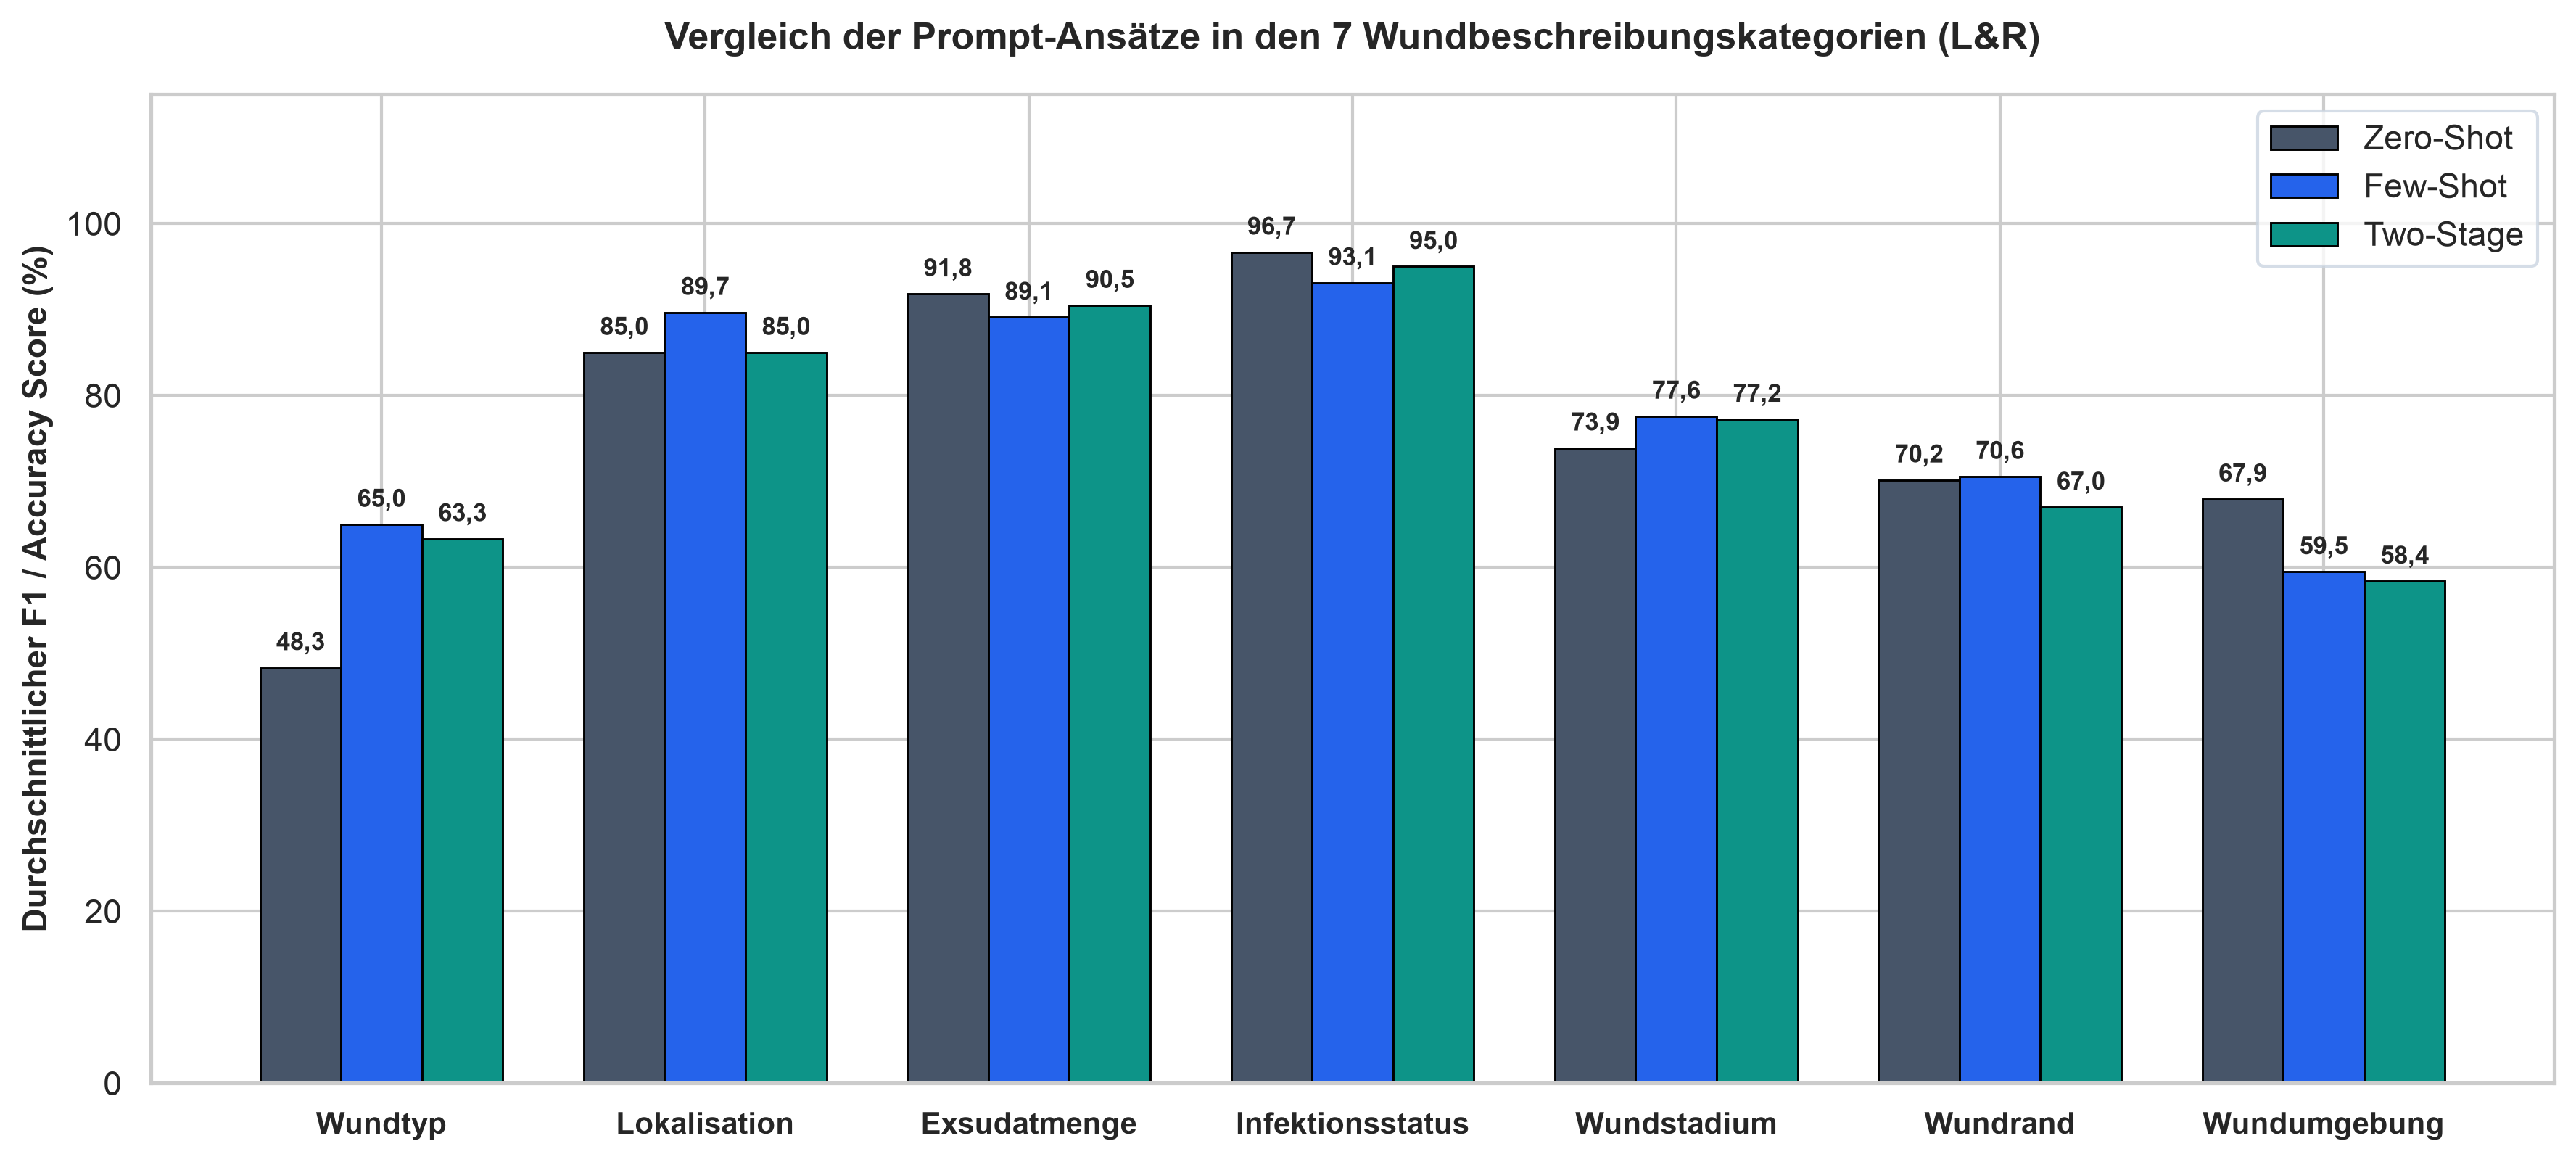

In [2]:
wund_rows = [
    "  Wundtyp (10/10)",
    "  Lokalisation (6/6)",
    "  Exsudatmenge (4/4)",
    "  Infektionsstatus (2/2)",
    "  Wundstadium (5/7)",
    "  Wundrand (7/7)",
    "  Wundumgebung (7/7)"
]

clean_labels = ["Wundtyp", "Lokalisation", "Exsudatmenge", "Infektionsstatus", "Wundstadium", "Wundrand", "Wundumgebung"]
df_wund = df_master.loc[wund_rows].copy()
df_wund.index = clean_labels

# Tabelle Lohmann & Rauscher (Best-of-Both)
df_wund_lr = df_wund[["lr_ZS", "lr_FS", "lr_2S"]].copy()
df_wund_lr.columns = ["Zero-Shot", "Few-Shot", "Two-Stage"]
df_wund_lr["FS vs ZS (Δ)"] = df_wund_lr["Few-Shot"] - df_wund_lr["Zero-Shot"]
df_wund_lr["2S vs ZS (Δ)"] = df_wund_lr["Two-Stage"] - df_wund_lr["Zero-Shot"]
df_wund_lr["2S vs FS (Δ)"] = df_wund_lr["Two-Stage"] - df_wund_lr["Few-Shot"]

print("=== WUNDBESCHREIBUNG: LOHMANN & RAUSCHER (2 EXPERTEN) ===")
try:
    display(df_wund_lr.round(1))
except NameError:
    print(df_wund_lr.round(1))

# Barplot Wundbeschreibung
sns.set_theme(style="whitegrid", font="sans-serif")
fig, ax = plt.subplots(figsize=(12, 5.5), dpi=300)
x = np.arange(len(clean_labels))
w = 0.25

ax.bar(x - w, df_wund_lr["Zero-Shot"], width=w, label="Zero-Shot", color="#475569", edgecolor="black", linewidth=0.7)
ax.bar(x, df_wund_lr["Few-Shot"], width=w, label="Few-Shot", color="#2563EB", edgecolor="black", linewidth=0.7)
ax.bar(x + w, df_wund_lr["Two-Stage"], width=w, label="Two-Stage", color="#0D9488", edgecolor="black", linewidth=0.7)

ax.set_xticks(x)
ax.set_xticklabels(clean_labels, fontweight="bold", fontsize=10)
ax.set_ylabel("Durchschnittlicher F1 / Accuracy Score (%)", fontweight="bold", fontsize=11)
ax.set_ylim(0, 115)
ax.set_title("Vergleich der Prompt-Ansätze in den 7 Wundbeschreibungskategorien (L&R)", fontweight="bold", fontsize=12.5, pad=15)
ax.legend(loc="upper right", frameon=True, facecolor="#FFFFFF", edgecolor="#CBD5E1")

for bar in ax.patches:
    val = bar.get_height()
    if val > 0:
        ax.annotate(f"{val:.1f}".replace(".", ","), xy=(bar.get_x() + bar.get_width()/2, val), xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

plt.tight_layout()
os.makedirs("../../exports/pngs", exist_ok=True)
plt.savefig("../../exports/pngs/prompt_ansatze_wundbeschreibung_detail.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Hauptkategorien-Vergleich & Prozentuale Differenzen (Deltas)

Hier vergleichen wir die 5 Hauptkategorien gegeneinander. Wir berechnen für jede Kategorie:
- **Few-Shot vs. Zero-Shot (Δ):** Gewinn/Verlust durch Few-Shot Beispiele im Prompt
- **Two-Stage vs. Zero-Shot (Δ):** Gewinn/Verlust durch die zweistufige Prozess-Entkopplung
- **Two-Stage vs. Few-Shot (Δ):** Direktvergleich der beiden fortgeschrittenen Ansätze

In [3]:
# Berechne Mittelwert Wundbeschreibung
wund_mean_lr = df_master.loc[wund_rows, ["lr_ZS", "lr_FS", "lr_2S"]].mean()
wund_mean_nu = df_master.loc[wund_rows, ["nurs_ZS", "nurs_FS", "nurs_2S"]].mean()

cat_map_lr = {
    "Wundbeschreibung (Mittelwert)": wund_mean_lr,
    "Debridement Methode": df_master.loc["  Debridement Methode (5/8)", ["lr_ZS", "lr_FS", "lr_2S"]],
    "Primärverband (Level 2)": df_master.loc["  Primärverband (9/16)", ["lr_ZS", "lr_FS", "lr_2S"]],
    "Sekundärverband": df_master.loc["  Sekundärverband (4/12)", ["lr_ZS", "lr_FS", "lr_2S"]],
    "Kompressionsprodukt": df_master.loc["  Kompressionsprodukte (5/37)", ["lr_ZS", "lr_FS", "lr_2S"]]
}

df_summary_lr = pd.DataFrame(cat_map_lr).T
df_summary_lr.columns = ["Zero-Shot", "Few-Shot", "Two-Stage"]
df_summary_lr["FS vs ZS (Δ)"] = df_summary_lr["Few-Shot"] - df_summary_lr["Zero-Shot"]
df_summary_lr["2S vs ZS (Δ)"] = df_summary_lr["Two-Stage"] - df_summary_lr["Zero-Shot"]
df_summary_lr["2S vs FS (Δ)"] = df_summary_lr["Two-Stage"] - df_summary_lr["Few-Shot"]

print("=== LOHMANN & RAUSCHER (2 EXPERTEN KONSENS): HAUPTKATEGORIEN ===")
try:
    display(df_summary_lr.round(1))
except NameError:
    print(df_summary_lr.round(1))

cat_map_nu = {
    "Wundbeschreibung (Mittelwert)": wund_mean_nu,
    "Debridement Methode": df_master.loc["  Debridement Methode (5/8)", ["nurs_ZS", "nurs_FS", "nurs_2S"]],
    "Primärverband (Level 2)": df_master.loc["  Primärverband (9/16)", ["nurs_ZS", "nurs_FS", "nurs_2S"]],
    "Sekundärverband": df_master.loc["  Sekundärverband (4/12)", ["nurs_ZS", "nurs_FS", "nurs_2S"]],
    "Kompressionsprodukt": df_master.loc["  Kompressionsprodukte (5/37)", ["nurs_ZS", "nurs_FS", "nurs_2S"]]
}

df_summary_nu = pd.DataFrame(cat_map_nu).T
df_summary_nu.columns = ["Zero-Shot", "Few-Shot", "Two-Stage"]
df_summary_nu["FS vs ZS (Δ)"] = df_summary_nu["Few-Shot"] - df_summary_nu["Zero-Shot"]
df_summary_nu["2S vs ZS (Δ)"] = df_summary_nu["Two-Stage"] - df_summary_nu["Zero-Shot"]
df_summary_nu["2S vs FS (Δ)"] = df_summary_nu["Two-Stage"] - df_summary_nu["Few-Shot"]

print("\n=== NURSIT (EXPERTE 3): HAUPTKATEGORIEN ===")
try:
    display(df_summary_nu.round(1))
except NameError:
    print(df_summary_nu.round(1))

=== LOHMANN & RAUSCHER (2 EXPERTEN KONSENS): HAUPTKATEGORIEN ===


,Zero-Shot,Few-Shot,Two-Stage,FS vs ZS (Δ),2S vs ZS (Δ),2S vs FS (Δ)
Wundbeschreibung (Mittelwert),76.3,77.8,76.6,1.5,0.4,-1.2
Debridement Methode,52.1,53.4,57.6,1.3,5.5,4.2
Primärverband (Level 2),62.1,64.7,70.4,2.6,8.3,5.7
Sekundärverband,6.7,23.3,5.0,16.7,-1.7,-18.3
Kompressionsprodukt,10.3,12.2,10.3,1.9,0.0,-1.9



=== NURSIT (EXPERTE 3): HAUPTKATEGORIEN ===


,Zero-Shot,Few-Shot,Two-Stage,FS vs ZS (Δ),2S vs ZS (Δ),2S vs FS (Δ)
Wundbeschreibung (Mittelwert),69.3,69.1,69.2,-0.2,-0.1,0.1
Debridement Methode,58.3,55.4,63.6,-3.0,5.2,8.2
Primärverband (Level 2),64.0,63.6,61.6,-0.4,-2.4,-2.0
Sekundärverband,4.4,4.0,7.3,-0.4,2.8,3.3
Kompressionsprodukt,0.0,12.8,2.1,12.8,2.1,-10.7


## 3. Visuelle Aufbereitung: Differenzen (Deltas in Prozentpunkten %)

Visualisierung der Gewinne/Verluste in Prozentpunkten durch den Einsatz von Few-Shot und Two-Stage.

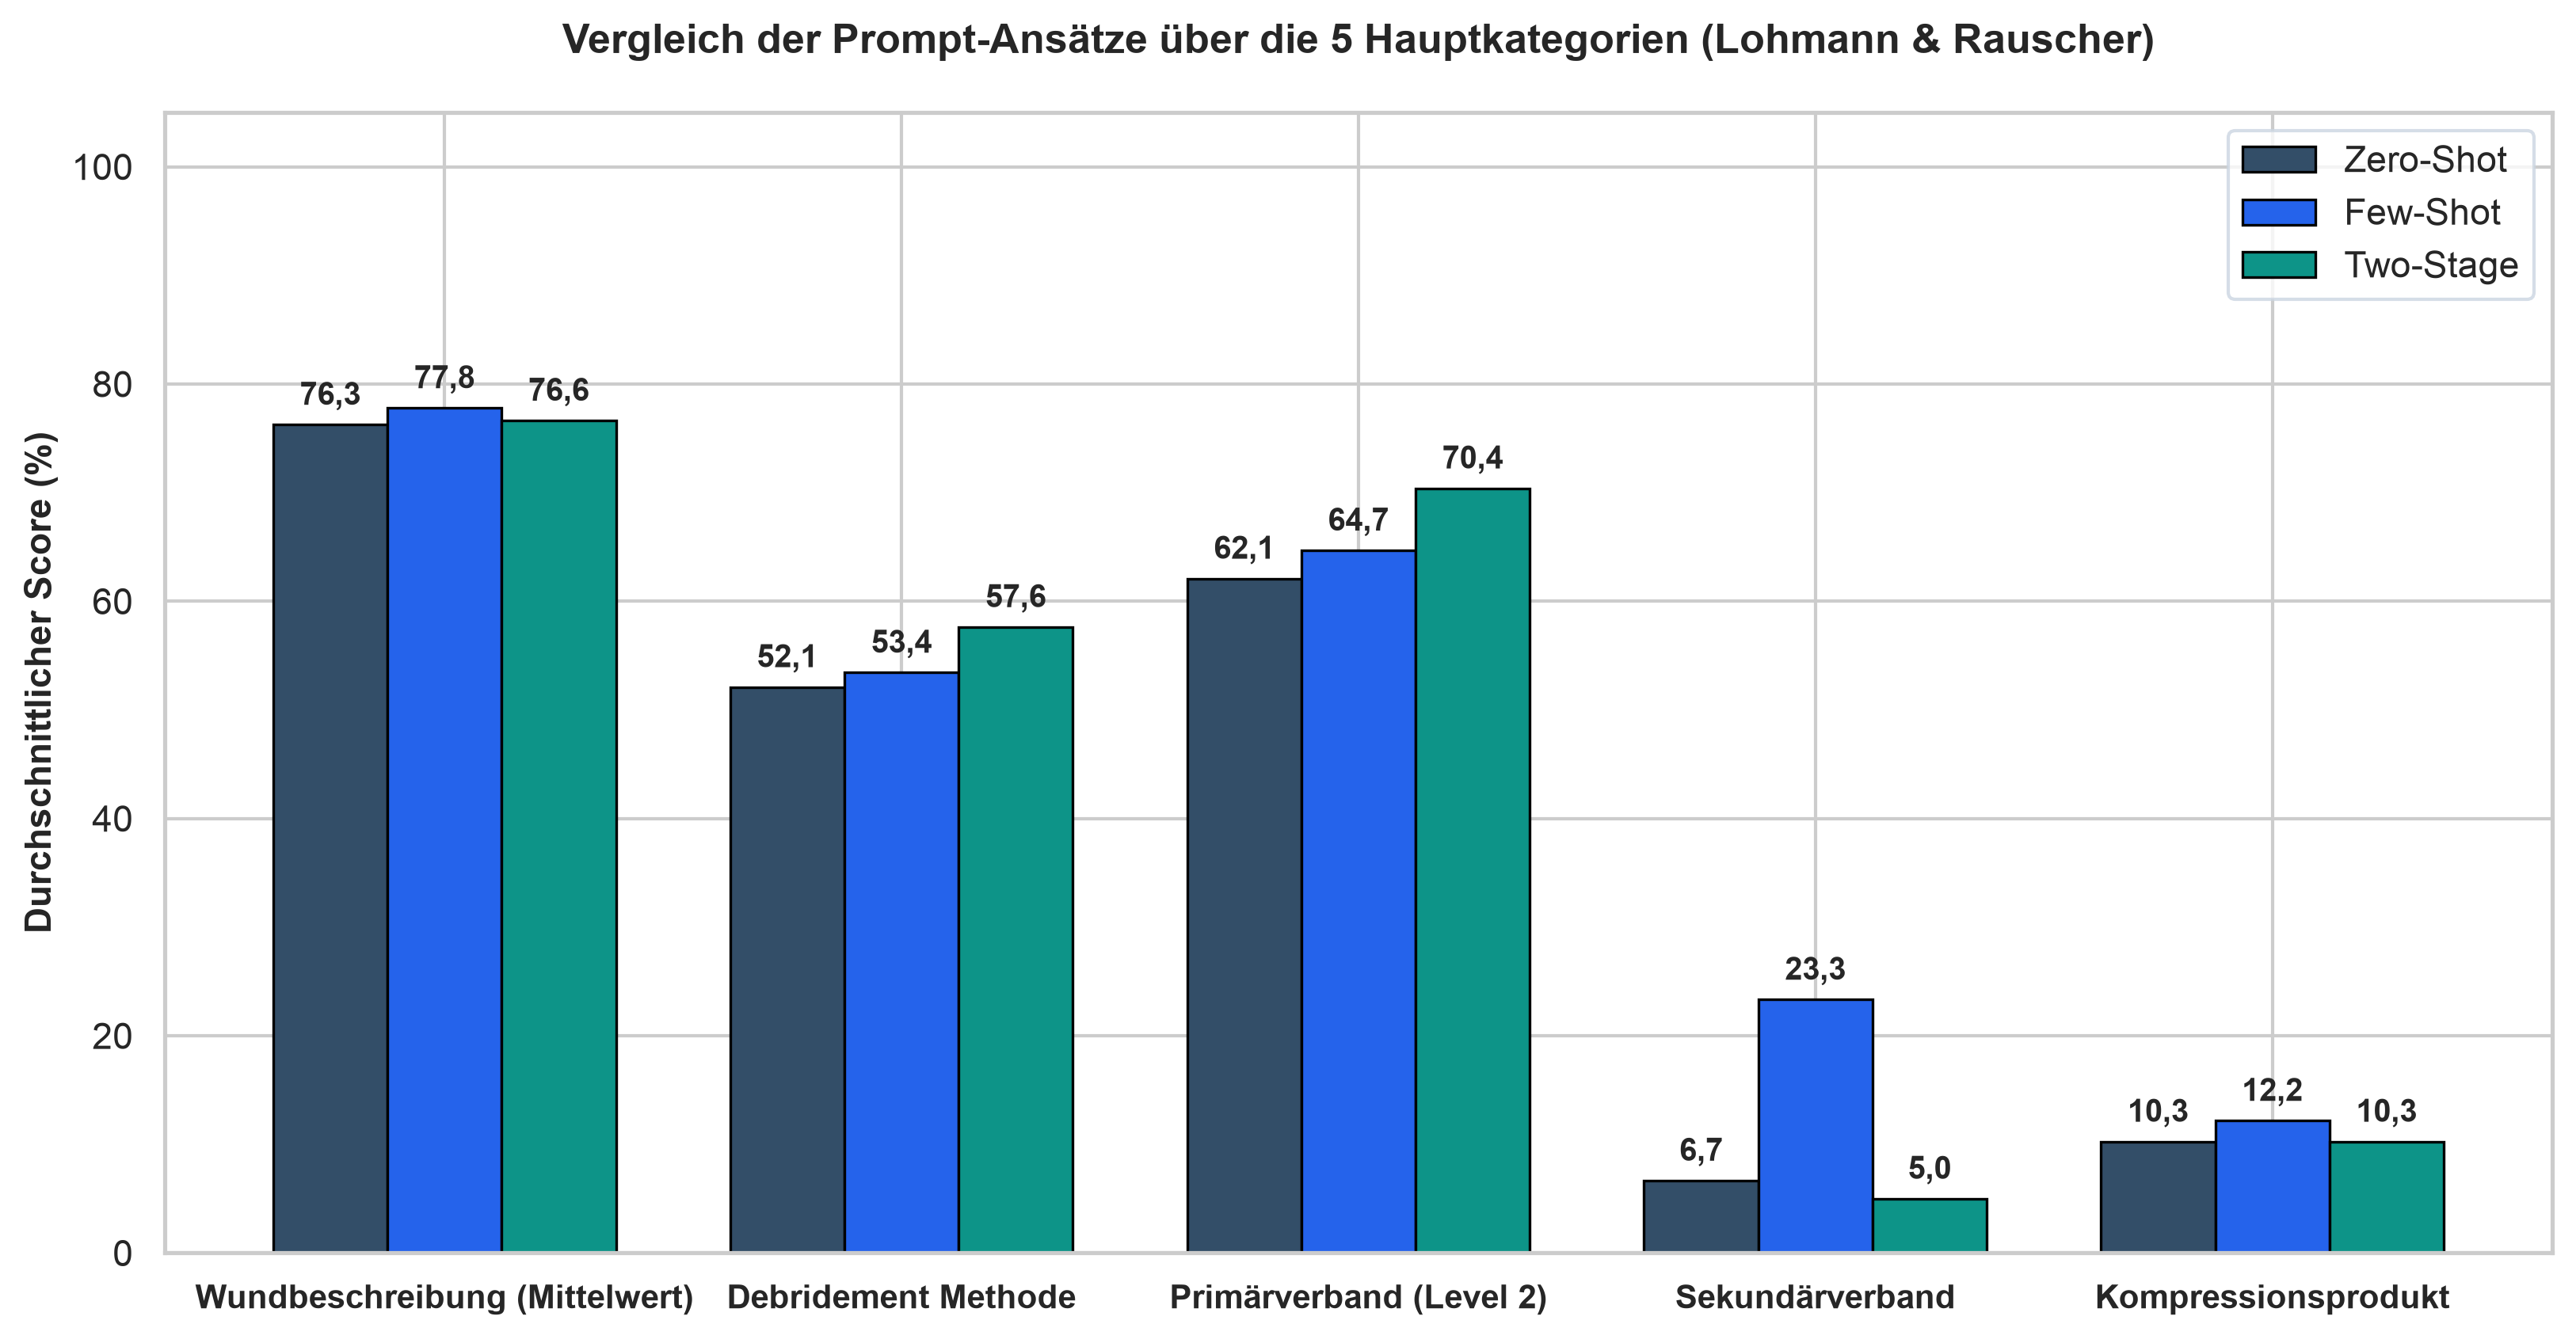

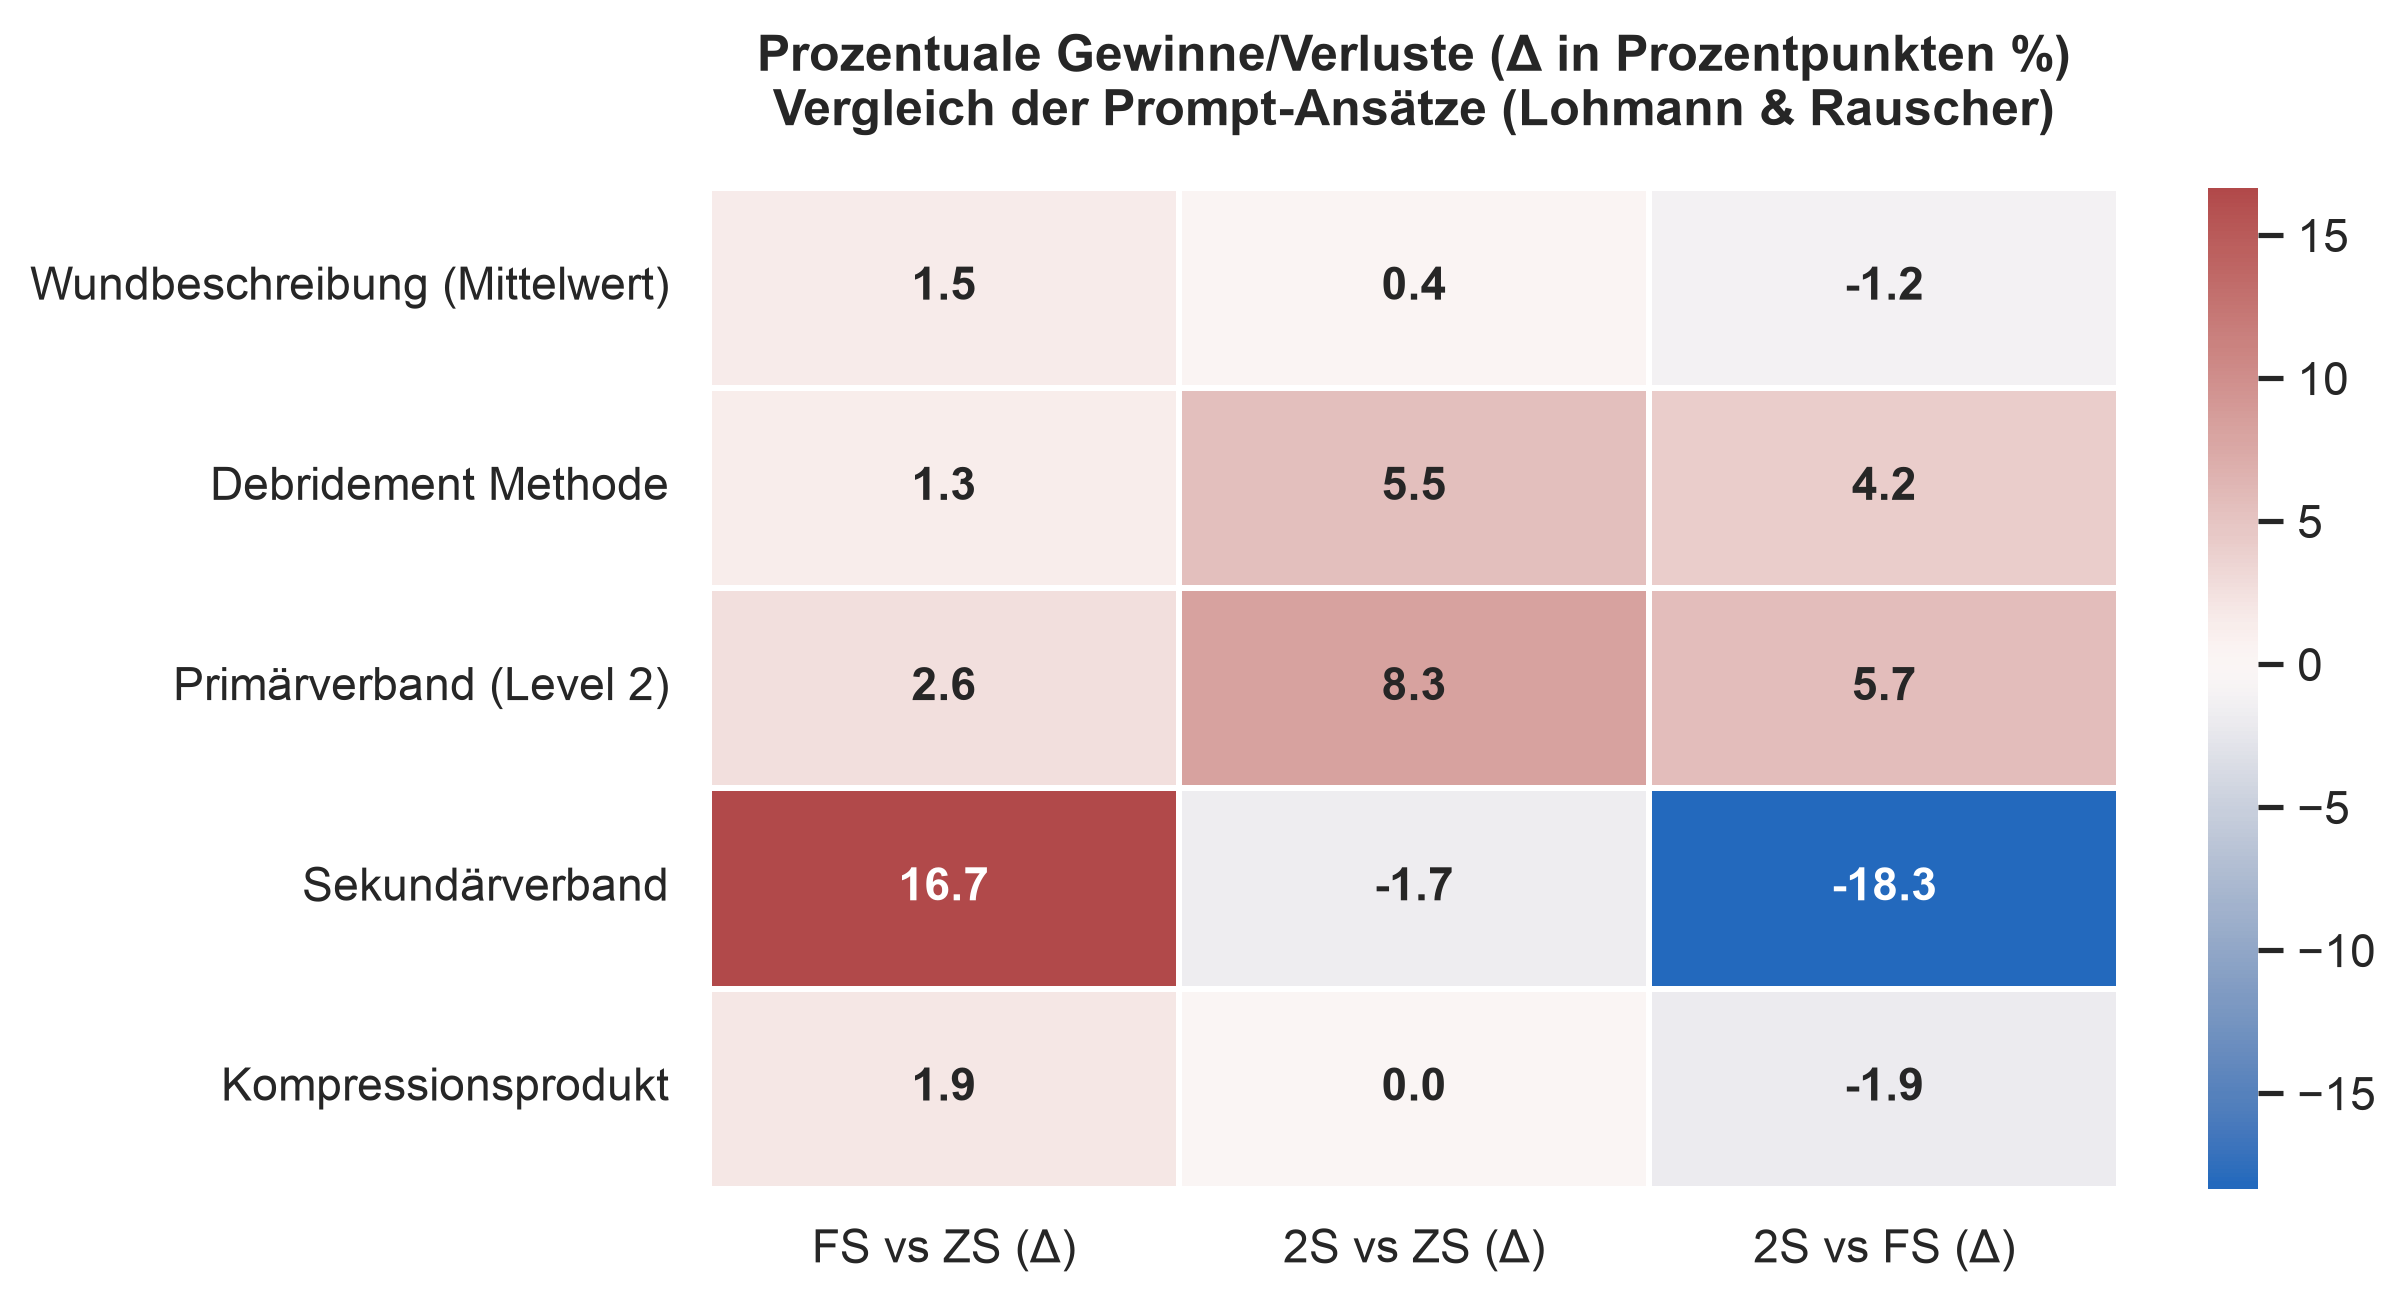

In [4]:
# Master Bar Plot der 5 Hauptkategorien für Lohmann & Rauscher
fig, ax = plt.subplots(figsize=(11, 5.8), dpi=300)
cats = df_summary_lr.index.tolist()
x = np.arange(len(cats))
w = 0.25

bars1 = ax.bar(x - w, df_summary_lr["Zero-Shot"], width=w, label="Zero-Shot", color="#334E68", edgecolor="black", linewidth=0.8)
bars2 = ax.bar(x, df_summary_lr["Few-Shot"], width=w, label="Few-Shot", color="#2563EB", edgecolor="black", linewidth=0.8)
bars3 = ax.bar(x + w, df_summary_lr["Two-Stage"], width=w, label="Two-Stage", color="#0D9488", edgecolor="black", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(cats, fontweight="bold", fontsize=10)
ax.set_ylabel("Durchschnittlicher Score (%)", fontweight="bold", fontsize=11)
ax.set_ylim(0, 105)
ax.set_title("Vergleich der Prompt-Ansätze über die 5 Hauptkategorien (Lohmann & Rauscher)", fontweight="bold", fontsize=12.5, pad=18)
ax.legend(loc="upper right", frameon=True, facecolor="#FFFFFF", edgecolor="#CBD5E1")

for bar in list(bars1) + list(bars2) + list(bars3):
    val = bar.get_height()
    if val > 0:
        ax.annotate(f"{val:.1f}".replace(".", ","), xy=(bar.get_x() + bar.get_width()/2, val), xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom", fontsize=9.5, fontweight="bold")

plt.tight_layout()
plt.savefig("../../exports/pngs/prompt_ansatze_hauptkategorien_vergleich.png", dpi=300, bbox_inches="tight")
plt.show()

# Heatmap der Deltas
df_delta_lr = df_summary_lr[["FS vs ZS (Δ)", "2S vs ZS (Δ)", "2S vs FS (Δ)"]].copy()
fig, ax = plt.subplots(figsize=(8.5, 4.5), dpi=300)
sns.heatmap(df_delta_lr, annot=True, fmt=".1f", cmap="vlag", center=0, cbar=True, ax=ax, linewidths=1.0, annot_kws={"fontweight": "bold", "fontsize": 11})
ax.set_title("Prozentuale Gewinne/Verluste (Δ in Prozentpunkten %)\nVergleich der Prompt-Ansätze (Lohmann & Rauscher)", fontweight="bold", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("../../exports/pngs/prompt_ansatze_delta_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Zusammenfassung & Erkenntnisse für die Masterarbeit

### Key Takeaways:
1. **Wundbeschreibung (Ø ~76–78%):**
   - **Few-Shot** erzielt mit **77,8%** das beste Ergebnis (+1,5% ggü. Zero-Shot).
   - **Two-Stage** bringt bei der reine Merkmalsbeschreibung keinen zusätzlichen Gewinn (76,6%).

2. **Primärverband (Level 2) — Gewinner: Two-Stage (+8,3%):**
   - **Two-Stage** dominiert mit **70,4%** (Zero-Shot: 62,1%, Few-Shot: 64,7%).
   - *Grund:* Die stufenweise Entkopplung (zuerst Beschreibung, dann begründete Produktwahl) ermöglicht der KI eine deutlich präzisere Zuordnung zu Produktfamilien.

3. **Debridement Methode — Gewinner: Two-Stage (+5,5%):**
   - **Two-Stage** erreicht **57,6%** (Zero-Shot: 52,1%, Few-Shot: 53,4%).
   - *Grund:* Auch bei der Indikation von Debridement-Verfahren stärkt der strukturierte Zwischenschritt die Logik.

4. **Sekundärverband — Gewinner: Few-Shot (+16,7%):**
   - **Few-Shot** springt auf **23,3%** (Zero-Shot: 6,7%, Two-Stage: 5,0%).
   - *Grund:* Bei freien Freitext-Checklisten mit vielen Produktbezeichnungen benötigt die KI konkrete In-Context-Beispiele, um das Syntaxformat korrekt zu treffen.